In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit

In [27]:
data = np.genfromtxt('ParameterEstimation_Ex1.txt')

In [28]:
def func(x, b):
    return 1 +0.65*x + b*x**2
def ln_likelihood(vals, func, b):
    return -np.sum(np.log(func(vals, b)))

def normalized_function(x,b):
    integral, _ = integrate.quad(lambda x: func(x, b), -0.95, 0.95)
    return func(x, b) / integral 

<BarContainer object of 20 artists>

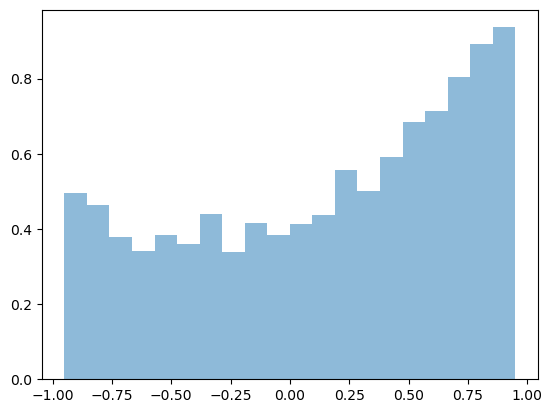

In [29]:
Nbins= 20
x_range = (-0.95, 0.95)
counts, edges = np.histogram(data, bins=Nbins, range=x_range, density=True)
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.bar(bin_centers, counts, width=edges[1] - edges[0], alpha=0.5, label='Sampled Distribution')

/var/folders/t0/dsmc290j5355qf2rn298qwb40000gn/T/ipykernel_37465/1527076331.py:4: RuntimeWarning: invalid value encountered in log
  return -np.sum(np.log(func(vals, b)))


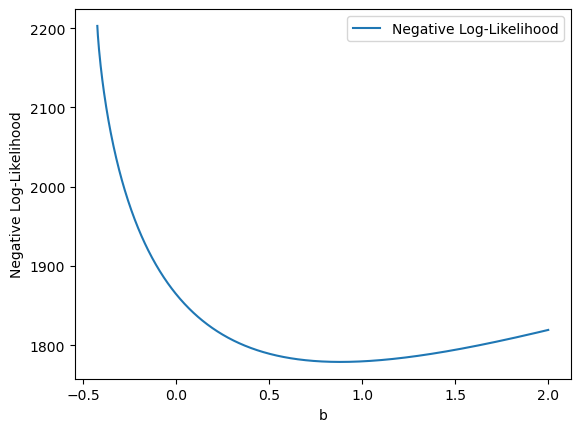

In [56]:
#plotting likelihood
b_values = np.linspace(-1, 2, 1000)
likelihood_values = [ln_likelihood(data, normalized_function, b) for b in b_values]
plt.plot(b_values, likelihood_values, label='Negative Log-Likelihood')
plt.xlabel('b')
plt.ylabel('Negative Log-Likelihood')
plt.legend()
plt.show()

In [57]:
m = Minuit(lambda b: ln_likelihood(data, normalized_function, b), b=0.5)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1779                       │              Nfcn = 19               │
│ EDM = 2.49e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b    │   0.88    │   0.14    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬────────┐
│   │      b │
├───┼────────┤
│ b │ 0.0181 │
└───┴────────┘

In [58]:
m.values['b']

0.8824171494780624

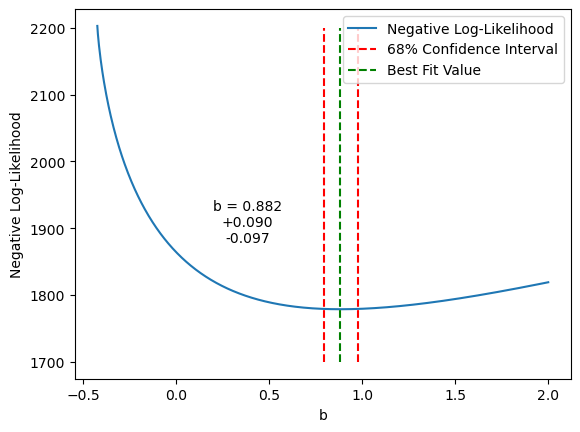

In [63]:
min_likelihood = ln_likelihood(data, normalized_function, m.values['b'])

#interval_vals = np.argwhere(likelihood_values < min_likelihood + 0.5)
interval_vals = np.where(likelihood_values < min_likelihood + 0.5)[0]

#print(f"68% confidence interval for b: [{b_values[interval_vals]}]")
b_p = b_values[interval_vals[-1]]
b_m = b_values[interval_vals[0]] 
sigma_p = m.values['b'] - b_m
sigma_m = b_p - m.values['b']
plt.plot(b_values, likelihood_values, label='Negative Log-Likelihood')
plt.vlines([b_m, b_p], ymin=1700, ymax=2200, colors='red', linestyles='dashed', label='68% Confidence Interval')
plt.vlines(m.values['b'], ymin=1700, ymax=2200, colors='green', linestyles='dashed', label='Best Fit Value')
plt.text(m.values['b']-0.5, min_likelihood + 100, f"b = {m.values['b']:.3f}\n+{sigma_p:.3f}\n-{sigma_m:.3f}", color='black', ha='center')
plt.xlabel('b')
plt.ylabel('Negative Log-Likelihood')
plt.legend()
plt.show()